In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

In [15]:
# Fixed Paramters
RE = 6371e3
mu = 3.986e14
ecliptic_obliquity = np.deg2rad(23.44)

In [16]:
# Direct Orbital Elements
a = 26564e3
e = 0.7411
i = np.deg2rad(63.4)
RAAN = np.deg2rad(50)
w = np.deg2rad(270)
t0 = np.deg2rad(0)

p = a*(1 - e**2)
t = np.linspace(0, 2*np.pi, 1000)

In [17]:
# Orbit Equation
r = p/(1 + e*np.cos(t))

x = r*np.cos(t)
y = r*np.sin(t)

r_pqw = np.vstack((x, y, np.zeros_like(x)))
r_t0 = p/(1 + e*np.cos(t0))
x_t0 = r_t0*np.cos(t0)
y_t0 = r_t0*np.sin(t0)

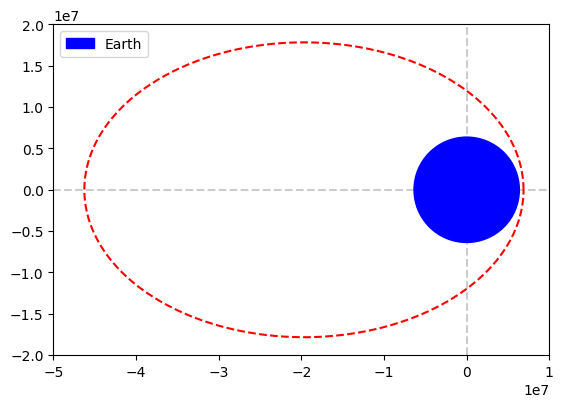

In [18]:
# Plot in Perifocal Frame
plt.axhline(0, color='k', ls='--', zorder=0, alpha=0.2)
plt.axvline(0, color='k', ls='--', zorder=0, alpha=0.2)

Earth = plt.Circle((0, 0), 6371e3, color='blue', label='Earth')
plt.gca().add_patch(Earth)

plt.plot(x, y, 'r--')
plt.gca().set_aspect('equal')

# plt.grid()
plt.xlim((-5e7, 1e7))
plt.ylim((-2e7, 2e7))
plt.legend()
plt.show()

In [19]:
# 3D Transformation using Orbital Elements
cw = np.cos(w)
sw = np.sin(w)
R_w = np.array([[cw, -sw, 0],
                [sw, cw, 0],
                [0, 0, 1]])

ci = np.cos(i)
si = np.sin(i)
R_i = np.array([[1, 0, 0],
                [0, ci, -si],
                [0, si, ci]])

cR = np.cos(RAAN)
sR = np.sin(RAAN)
R_R = np.array([[cR, -sR, 0],
                [sR, cR, 0],
                [0, 0, 1]])

r_eci = (R_R @ (R_i @ (R_w @ r_pqw)))
print(r_eci.shape)

(3, 1000)


In [8]:
# Meshing Earth, Equatorial Plane, Ecliptic Plane and Orbital Plane

u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)
u, v = np.meshgrid(u, v)

xE = RE*np.cos(u)*np.sin(v)
yE = RE*np.sin(u)*np.sin(v)
zE = RE*np.cos(v)

xS = xE*5e-2
yS = yE*5e-2
zS = zE*5e-2

R_EQ = np.linspace(0, 10*RE, 50)
t_EQ = np.linspace(0, 2*np.pi, 100)
R_EQ_grid, t_EQ_grid = np.meshgrid(R_EQ, t_EQ)

xEQ = R_EQ_grid*np.cos(t_EQ_grid)
yEQ = R_EQ_grid*np.sin(t_EQ_grid)
zEQ = np.zeros_like(xEQ)


coe = np.cos(ecliptic_obliquity)
soe = np.sin(ecliptic_obliquity)

xEL = xEQ
yEL = yEQ*coe - zEQ*soe
zEL = yEQ*soe + zEQ*coe


xyzEQ = np.vstack((xEQ.flatten(), yEQ.flatten(), zEQ.flatten()))
# print(xyzEQ.shape)
xyzOR = (R_R @ (R_i @ (R_w @ xyzEQ)))
xOR = xyzOR[0, :].reshape(xEQ.shape)
yOR = xyzOR[1, :].reshape(yEQ.shape)
zOR = xyzOR[2, :].reshape(zEQ.shape)

In [9]:
# Line of Nodes

ptAN = np.array([10*RE*np.cos(RAAN), 10*RE*np.sin(RAAN), 0])
ptK = np.array([0, 0, 10*RE])
pth = (R_R @ (R_i @ (R_w @ ptK)))
ptI = np.array([10*RE, 0, 0])
pte = (R_R @ (R_i @ (R_w @ ptI)))

In [10]:
# Rodrigues Formula Function
def Rotate_Axis(Initial_Vector, Axis_Vector, Angle):
    ''' Input Angle can be an array
    The output is a set of Vectors for each Angle input
    Angle Input shall be in Radians
    '''
    Rotated_Vector = np.zeros((3, Angle.shape[0]))
    Axis_Vector_Norm = Axis_Vector/np.linalg.norm(Axis_Vector)

    Rotated_Vector += Initial_Vector[:, None]*np.cos(Angle[None, :])
    # print(Rotated_Vector.shape)
    Rotated_Vector += np.cross(Axis_Vector_Norm, Initial_Vector)[:, None]*np.sin(Angle[None, :])
    Rotated_Vector += Axis_Vector_Norm[:, None]*np.dot(Axis_Vector_Norm, Initial_Vector)*(1 - np.cos(Angle[None, :]))
    return Rotated_Vector

In [11]:
# Angle Arcs and True Anomaly
Angle_R = 2*RE

tRAAN = np.linspace(0, RAAN, 100)
xRAAN = 2*RE*np.cos(tRAAN)
yRAAN = 2*RE*np.sin(tRAAN)
zRAAN = np.zeros_like(xRAAN)

ti = np.linspace(0, i, 100)
xyz_i = Rotate_Axis(ptK/5, ptAN, ti)

tw = np.linspace(0, w, 100)
xyz_w = Rotate_Axis(ptAN/5, pth, tw)


ptTA = [x_t0, y_t0, 0]
xyz_t0 = (R_R @ (R_i @ (R_w @ ptTA)))

In [12]:
# Orbit in Earth Centered Inertial Frame
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=[0, 10*RE], y=[0, 0], z=[0, 0], 
                           mode='lines', name='X Axis (Vernal Equinox)', legendgroup='ICA'))
fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 10*RE], z=[0, 0], 
                           mode='lines', name='Y Axis', legendgroup='ICA'))
fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[0, 10*RE], 
                           mode='lines', name='Z Axis (North Pole)', legendgroup='ICA'))

fig.add_trace(go.Scatter3d(x=[0, pth[0]], y=[0, pth[1]], z=[0, pth[2]],
                           mode='lines', name='Angular Momentum (Direction)', visible='legendonly', legendgroup='AM_Incl'))
fig.add_trace(go.Scatter3d(x=xyz_i[0, :], y=xyz_i[1, :], z=xyz_i[2, :],
                           mode='lines', name=f'Inclination: {np.rad2deg(i)}°', visible='legendonly', legendgroup='AM_Incl'))


fig.add_trace(go.Scatter3d(x=[0, ptAN[0]], y=[0, ptAN[1]], z=[0, ptAN[2]],
                           mode='lines', name='Ascending Node', visible='legendonly', legendgroup='AN_RAAN_Ecc_AP'))
fig.add_trace(go.Scatter3d(x=xRAAN, y=yRAAN, z=zRAAN,
                           mode='lines', name=f'RAAN: {np.rad2deg(RAAN)}°', visible='legendonly', legendgroup='AN_RAAN_Ecc_AP'))
fig.add_trace(go.Scatter3d(x=[0, pte[0]], y=[0, pte[1]], z=[0, pte[2]],
                           mode='lines', name='Eccentricity (Direction)', visible='legendonly', legendgroup='AN_RAAN_Ecc_AP'))
fig.add_trace(go.Scatter3d(x=xyz_w[0, :], y=xyz_w[1, :], z=xyz_w[2, :],
                           mode='lines', name=f'Argument of Perigee: {np.rad2deg(w)}°', visible='legendonly', legendgroup='AN_RAAN_Ecc_AP'))

fig.add_trace(go.Scatter3d(x=[0, xyz_t0[0]], y=[0, xyz_t0[1]], z=[0, xyz_t0[2]],
                           mode='lines', name='Radius Vector (Satellite)'))

fig.add_trace(go.Surface(x=xE, y=yE, z=zE, 
                         showscale=False, 
                         colorscale=[[0, 'blue'], [1, 'blue']]))
fig.add_trace(go.Surface(x=xS + xyz_t0[0], y=yS + xyz_t0[1], z=zS + xyz_t0[2],
                         showscale=False,
                         colorscale=[[0, 'yellow'], [1, 'yellow']],
                         showlegend=True,
                         name='Satellite'))

fig.add_trace(go.Surface(x=xEQ, y=yEQ, z=zEQ,
                         showscale=False,
                         opacity=0.3,
                         colorscale=[[0, 'orange'], [1, 'orange']],
                         name="Equatorial Plane",
                         showlegend=True))

fig.add_trace(go.Surface(x=xEL, y=yEL, z=zEL,
                         showscale=False,
                         opacity=0.3,
                         colorscale=[[0, 'blue'], [1, 'blue']],
                         name="Ecliptic Plane",
                         showlegend=True))

fig.add_trace(go.Surface(x=xOR, y=yOR, z=zOR,
                         showscale=False,
                         opacity=0.3,
                         colorscale=[[0, 'white'], [1, 'white']],
                         name="Orbital Plane",
                         showlegend=True,
                         visible='legendonly'))

fig.add_trace(go.Scatter3d(x=r_eci[0, :],
                           y=r_eci[1, :], 
                           z=r_eci[2, :], 
                           mode='lines', name='Orbit',
                           line=dict(width=7, color='grey')))

fig.update_layout(
    margin=dict(l=0, r=75, t=25, b=0),
    scene=dict(
               xaxis=dict(showgrid=False, zeroline=False, visible=False),
               yaxis=dict(showgrid=False, zeroline=False, visible=False),
               zaxis=dict(showgrid=False, zeroline=False, visible=False),
               aspectmode='data'),
               paper_bgcolor="black",
               legend=dict(font=dict(color="white"), bordercolor='white'))

fig.show(config=dict(responsive=True))